**Dimensionality Reduction - PCA (Principal Component Analysis)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('/content/clean_data.csv')  #change it with the correct path

Apply PCA to reduce feature dimensionality while maintaining variance.

In [3]:
# Separate features (X) and target (y)
X = df.drop('num', axis=1)  # Assuming 'num' is your target column
y = df['num']

# Apply PCA to the features
pca = PCA()
X_pca = pca.fit_transform(X)
X_pca

array([[ 1.16272226, -0.92962183,  3.21234102, ...,  0.22264177,
         0.49702295,  0.08650595],
       [ 3.21783047, -1.45102084, -0.48153238, ..., -1.03282851,
        -0.94247249,  1.07869059],
       [ 3.14360376,  0.63656877, -0.36430077, ...,  0.34028136,
         0.8951757 , -0.23083604],
       ...,
       [ 1.87570429,  2.38177479, -0.16316278, ...,  0.53089075,
         0.05731892,  0.31099315],
       [-1.31332548, -1.51469484, -0.14011541, ...,  1.05189887,
         0.48402924,  1.03113566],
       [-2.60110963,  1.41284182,  0.5870924 , ..., -0.59161447,
        -0.59664197,  0.22361365]])

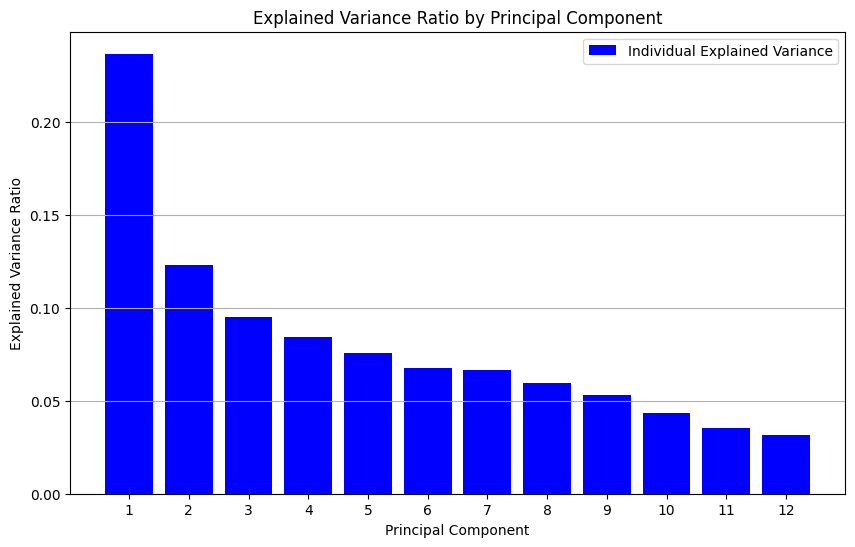

In [14]:
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, color='b', label='Individual Explained Variance')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(axis='y')
plt.legend()
plt.show()

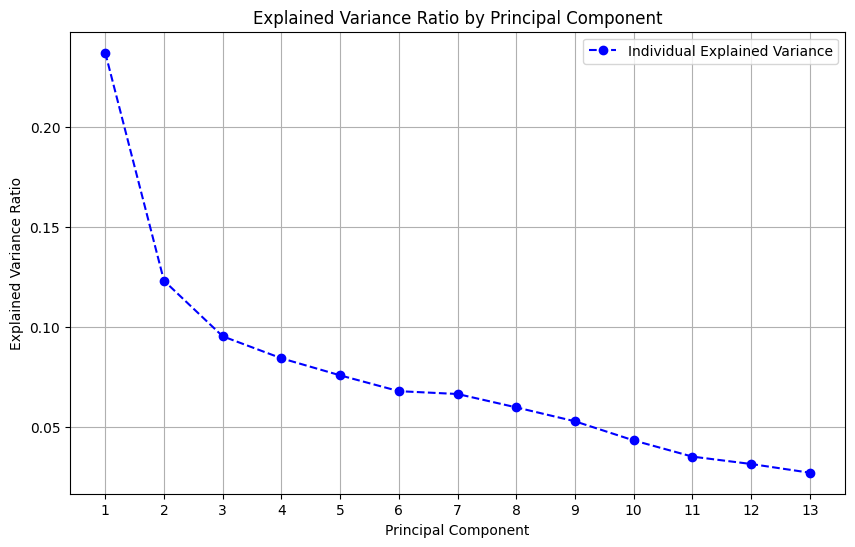

In [6]:
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='b', label='Individual Explained Variance')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid()
plt.legend()

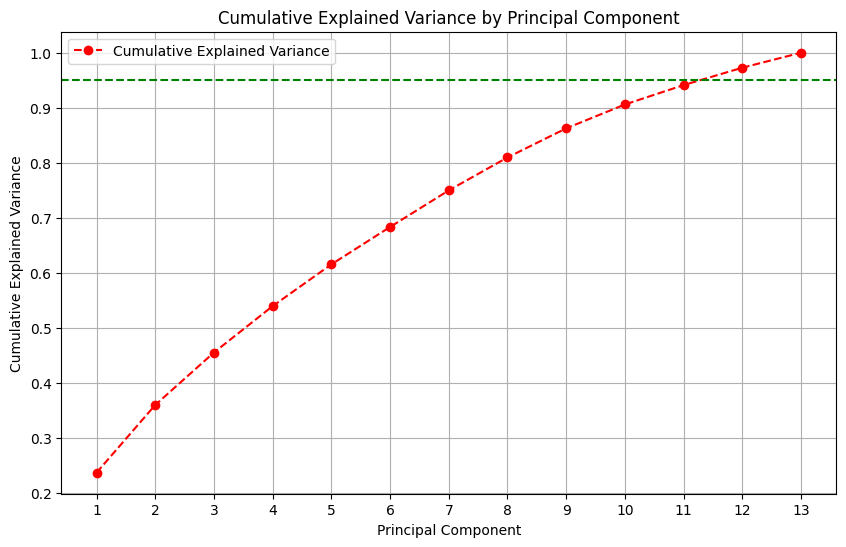

In [7]:
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='r', label='Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.axhline(y=0.95, color='g', linestyle='--')  # threshold for 95%
plt.grid()
plt.legend()
plt.show()

In [8]:
pca = PCA(n_components=12)
X_pca = pca.fit_transform(X)

In [10]:
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])
pca_df['num'] = df['num'].reset_index(drop=True)
pca_df.to_csv('pca_transformed_data.csv', index=False)

In [11]:
sns.pairplot(pca_df,hue='num')
plt.suptitle('Pairwise Scatter Plots of PCA Components', y=1.02)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [13]:
from google.colab import files
files.download('pca_transformed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>